In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Load Cleaned Dataset
df = pd.read_csv('breast-cancer-updated.csv')

# Split features and label
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Step 1: Feature Selection (Fisher Score and Chi-Square)

# Standardize for Fisher Score
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X)

# Normalize for Chi-Square
scaler_minmax = MinMaxScaler()
X_scaled_minmax = scaler_minmax.fit_transform(X)

# Fisher Score
def fisher_score(X, y):
    classes = np.unique(y)
    scores = []
    for i in range(X.shape[1]):
        numerator = 0
        denominator = 0
        for c in classes:
            idx = (y == c)
            class_mean = np.mean(X[idx, i])
            overall_mean = np.mean(X[:, i])
            numerator += sum(idx) * (class_mean - overall_mean) ** 2
            denominator += np.sum((X[idx, i] - class_mean) ** 2)
        scores.append(numerator / (denominator + 1e-6))
    return np.array(scores)

fisher_scores = fisher_score(X_scaled_std, y)
fisher_df = pd.DataFrame({
    'Feature': X.columns,
    'FisherScore': fisher_scores
}).sort_values(by='FisherScore', ascending=False)

# Print Fisher Score Results
print("Top Features by Fisher Score:")
print(fisher_df.head(10))

# Chi-Square
chi2_scores, _ = chi2(X_scaled_minmax, y)
chi2_df = pd.DataFrame({
    'Feature': X.columns,
    'ChiSquare': chi2_scores
}).sort_values(by='ChiSquare', ascending=False)

# Print Chi-Square Results
print("\nTop Features by Chi-Square:")
print(chi2_df.head(10))

Top Features by Fisher Score:
                 Feature  FisherScore
27  concave points_worst     1.700856
22       perimeter_worst     1.583676
7    concave points_mean     1.519711
20          radius_worst     1.518134
2         perimeter_mean     1.229692
23            area_worst     1.166843
0            radius_mean     1.141060
3              area_mean     1.010689
6         concavity_mean     0.941434
26       concavity_worst     0.770180

Top Features by Chi-Square:
                 Feature  ChiSquare
7    concave points_mean  52.405743
27  concave points_worst  46.341648
6         concavity_mean  46.186395
23            area_worst  35.043882
22       perimeter_worst  34.438091
20          radius_worst  34.124937
26       concavity_worst  31.563031
3              area_mean  29.328594
2         perimeter_mean  26.528902
0            radius_mean  24.897293


In [3]:

# Merge Results
merged_df = fisher_df.merge(chi2_df, on='Feature')

# Select Top 10 Features
selected_features = merged_df.sort_values(by=['FisherScore', 'ChiSquare'], ascending=False).head(10)['Feature'].tolist()

# Print Selected Top 10 Features
print("\nFinal Selected Top 10 Features (after merging Fisher and Chi-Square):")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")



Final Selected Top 10 Features (after merging Fisher and Chi-Square):
1. concave points_worst
2. perimeter_worst
3. concave points_mean
4. radius_worst
5. perimeter_mean
6. area_worst
7. radius_mean
8. area_mean
9. concavity_mean
10. concavity_worst


In [4]:
# Step 2: Create New Dataset with Selected Features and Train Model

# Create new dataset with Top 10 Features
X_selected = df[selected_features]

# Split the data into training, validation, and testing sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Train RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

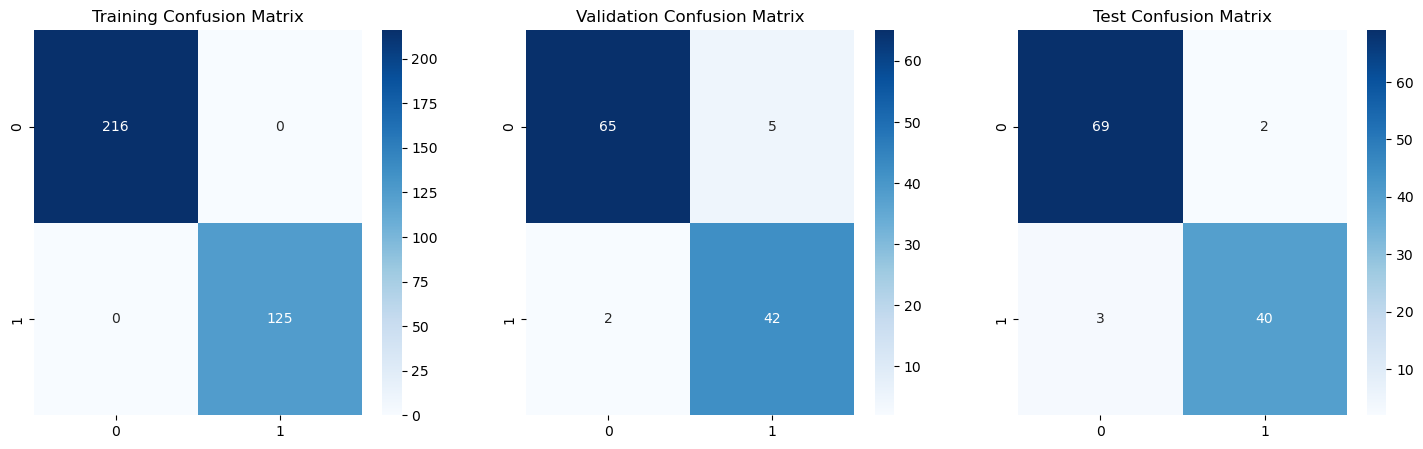

In [5]:
#Step 3: Evaluate Model with Confusion Matrices

# Predictions on train, validation, and test sets
y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Training Confusion Matrix')
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Validation Confusion Matrix')
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', ax=axes[2], cmap='Blues')
axes[2].set_title('Test Confusion Matrix')
plt.show()


Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       125

    accuracy                           1.00       341
   macro avg       1.00      1.00      1.00       341
weighted avg       1.00      1.00      1.00       341

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        70
           1       0.89      0.95      0.92        44

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114

Test Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95 

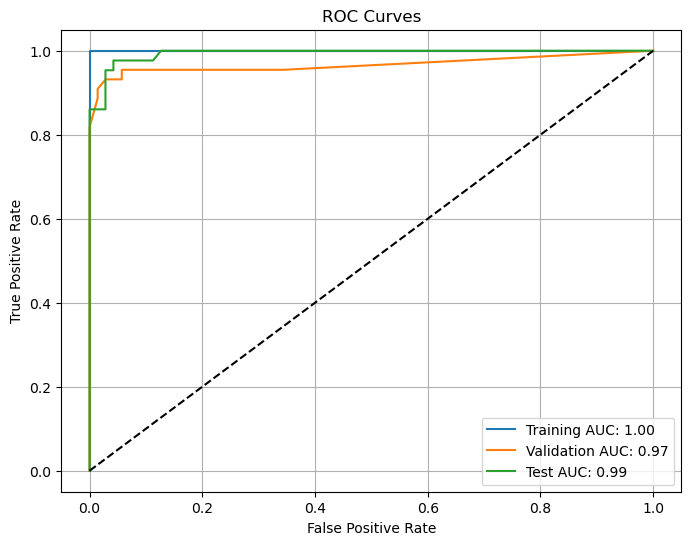

In [7]:
# Step 4: Calculate Performance Metrics and Plot ROC Curves

# Classification Reports
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# ROC Curves and AUC Scores
probs_train = rf.predict_proba(X_train)[:, 1]
probs_val = rf.predict_proba(X_val)[:, 1]
probs_test = rf.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, probs_train)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_val, tpr_val, _ = roc_curve(y_val, probs_val)
roc_auc_val = auc(fpr_val, tpr_val)

fpr_test, tpr_test, _ = roc_curve(y_test, probs_test)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f'Training AUC: {roc_auc_train:.2f}')
plt.plot(fpr_val, tpr_val, label=f'Validation AUC: {roc_auc_val:.2f}')
plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid()
plt.show()
